In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
# Read the mhd file from data
import os
import matplotlib.pyplot as plt

import mpl_interactions as pli
from gecco import patient_data
import gecco as fc
import numpy as np
from gecco.utils import nrrd_to_mhd, cropping_tool

## This script generates the rest of the code to run batch GECCO simulations

The first few cells are to check the simulation density and phantom are aligned, manually

Modify the dictionary so that the last integer specifies the right simulation to load for each of the simulations

## Running the GECCO sims

The last few cells generate the scripts for running the simulations

Best to make a test output directory with only 2 projections

From there create the full simulations

In [46]:
nrrd_files = {'0':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd',[1,0,2],[313,511,111,367,None,None],2],
            '1':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd',[1,0,2],[313,511,111,367,None,None],2],
            '2':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd',[1,0,2],[287,511,2,392,15,78],2],
            '3':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd',[1,0,2],[254,None,None,None,None,None],1],
            '4':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd',[2,1,0],[None,114,None,None,None,None],1],
            '5':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd',[2,1,0],[None,72,None,None,None,None],1],
            '6':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd',[2,1,0],[None,70,None,None,None,None],None],
            '7':['/home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd',[1,0,2],[367,None,None,None,None,None],None]}

In [47]:
file_index = '7'

## Load the simulation

In [48]:
nrrd_file = nrrd_files[file_index][0]
sim_num = nrrd_files[file_index][3]

In [136]:
phantom = patient_data.patient_phantom(nrrd_file, 1e10, reload=True, sim_num=sim_num)

[2025-01-17 16:40:58,256] {patient_data.py:69} INFO - Reloading phantom
[2025-01-17 16:40:58,257] {patient_data.py:161} INFO - Found existing directory. Using mhd file Pelvis_Prostate_Patient_5_phantom.mhd
[2025-01-17 16:40:58,378] {patient_data.py:191} INFO - Phantom loaded from pickle file fastmc_1e06_10angles.pkl
[2025-01-17 16:40:58,444] {patient_data.py:197} INFO - Loading ggems files

[2025-01-17 16:40:58,445] {patient_data.py:228} INFO - Using the first detector layer ggems files
[2025-01-17 16:40:58,445] {patient_data.py:251} INFO - No flood file found for the first layer
[2025-01-17 16:40:58,446] {patient_data.py:266} INFO - ggems files loaded
[2025-01-17 16:40:58,446] {patient_data.py:267} INFO -     Scatter files:


## Check the alignment of the density and the phantom

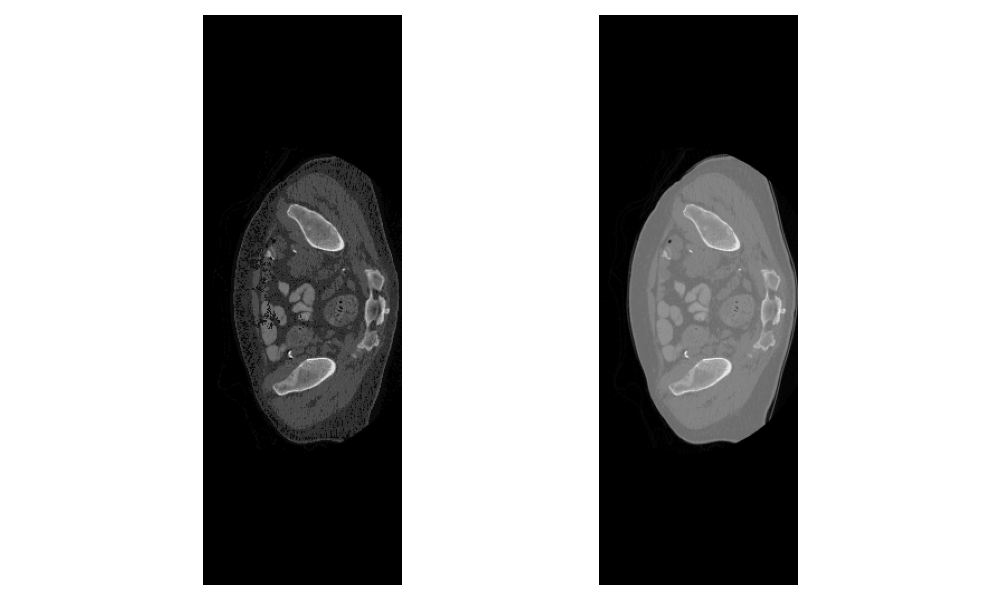

In [139]:
plt.figure(figsize=[10,6])
plt.subplot(121)
plt.imshow(np.flipud(phantom.phantom[40,:,:]),cmap='gray',aspect='equal')
plt.axis('off')
plt.subplot(122)
plt.imshow(np.flipud(phantom.density[40,:,:]),cmap='gray',aspect='equal')
plt.axis('off')
plt.tight_layout()

In [138]:
np.flipud(phantom.phantom[40, 230:315,40:100])[np.flipud(phantom.phantom)[40, 230:315,40:100] == 2] = 100
np.flipud(phantom.phantom)[40, 230:315,40:100][np.flipud(phantom.phantom)[40, 230:315,40:100] == 3] = 101

phantom.phantom[phantom.phantom == 2] = 4
phantom.phantom[phantom.phantom == 3] = 5

phantom.phantom[phantom.phantom == 100] = 2
phantom.phantom[phantom.phantom == 101] = 3


In [134]:
print(phantom.geomet)
phantom.geomet.offDetector = np.array([0,0])
phantom.geomet.dDetector = np.array([2.24,2.24])
phantom.geomet.sDetector = phantom.geomet.dDetector*phantom.geomet.nDetector
phantom.is_fullfan = True

TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1510 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [360 360]
Size of each pixel (dDetector) = [1.12 1.12] mm
Total size of the detector (sDetector) = [403.2 403.2] mm
-----
Image parameters
Number of voxels (nVoxel) = [145 512 178]
Total size of the image (sVoxel) = [185.32102    654.374912   266.99899435] mm
Size of each voxel (dVoxel) = [1.278076   1.278076   1.49999435] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [   0 -160] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad


Low energy image

In [84]:
phantom.energies = np.array([  10,   20,   30,   40,   50,   60,   70,   80,  84.5, 90, 90.58,  100,  300,
        500,  700,  900, 1000, 2000, 4000, 6000])

In [85]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([ 80,84.5,85])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False,energies = phantom.energies)

[2025-01-17 16:01:41,668] {patient_data.py:616} INFO - Making a list of angles
[2025-01-17 16:01:41,669] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-17 16:01:41,674] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
18
18
[2025-01-17 16:01:42,161] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-17 16:01:42,193] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-17 16:01:42,194] {ggems_simulate.py:622} INFO -     Simulating 84.5 keV
[2025-01-17 16:01:42,209] {ggems_simulate.py:701} INFO -         Attenuation at 84.5 keV for SchneiderMaterialsWeight2 is 0.17910210739439197
[2025-01-17 16:01:42,223] {ggems_simulate.py:701} INFO -         Attenuation at 84.5 keV for SchneiderMaterialsWeight3 is 0.17687572488053876
[2025-01-17 16:01:42,237] {ggems_simulate.py:701} INFO -         Attenuation at 84.5 keV for SchneiderMa

In [86]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

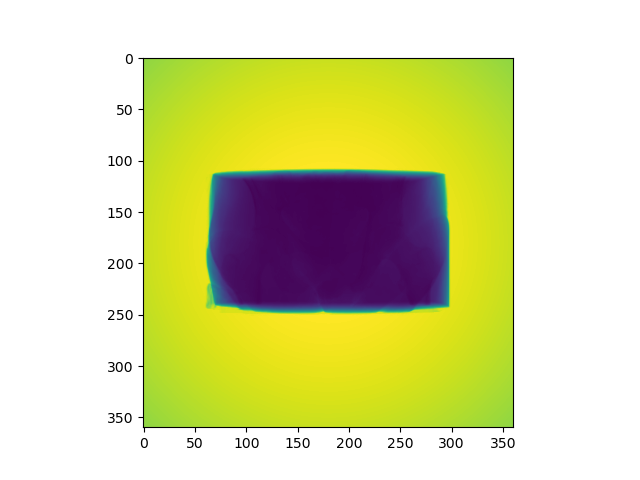

In [87]:
plt.figure()
pli.hyperslicer(phantom.primary_projections)

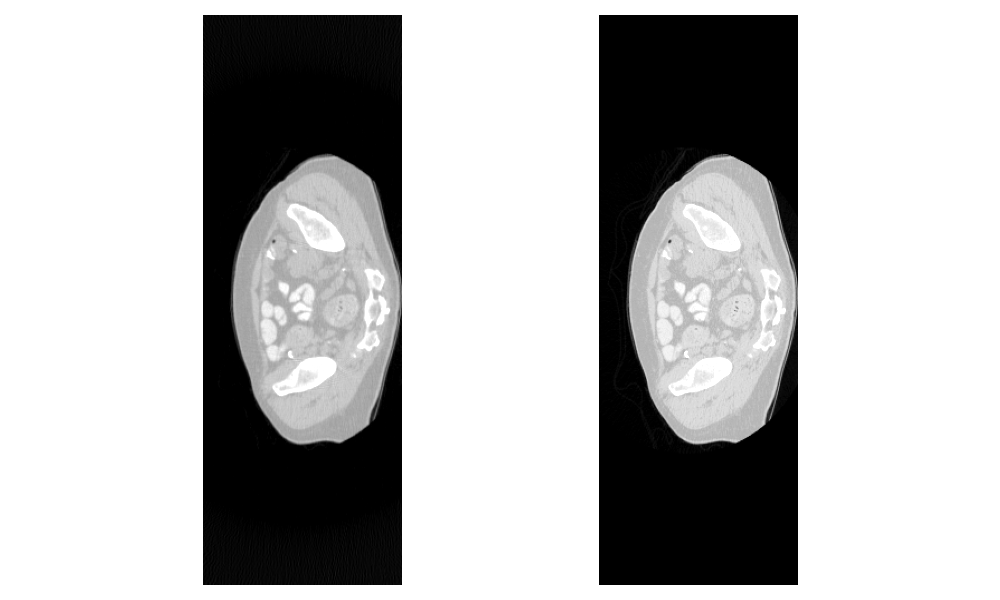

In [88]:
plt.figure(figsize=[10,6])
plt.subplot(121)
plt.imshow(np.flipud(phantom.img[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.img[40],40),vmax=np.percentile(phantom.img[40],98))
# plt.title('GECCO CBCT')
plt.axis('off')
plt.subplot(122)
plt.imshow(np.flipud(phantom.density[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.density[40],40),vmax=np.percentile(phantom.density[40],98))
# plt.title('Clinical CT')
plt.axis('off')
plt.tight_layout()

In [89]:
phantom_img_low = phantom.img.copy() + 0.00001

High energy image

In [90]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([90, 90.58, 91])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False)

[2025-01-17 16:01:55,219] {patient_data.py:616} INFO - Making a list of angles
[2025-01-17 16:01:55,220] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-17 16:01:55,222] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
18
18
[2025-01-17 16:01:55,437] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-17 16:01:55,454] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-17 16:01:55,455] {ggems_simulate.py:622} INFO -     Simulating 90.58 keV
[2025-01-17 16:01:55,463] {ggems_simulate.py:701} INFO -         Attenuation at 90.58 keV for SchneiderMaterialsWeight2 is 0.17377957285492182
[2025-01-17 16:01:55,471] {ggems_simulate.py:701} INFO -         Attenuation at 90.58 keV for SchneiderMaterialsWeight3 is 0.17242661055410696
[2025-01-17 16:01:55,478] {ggems_simulate.py:701} INFO -         Attenuation at 90.58 keV for Schneid

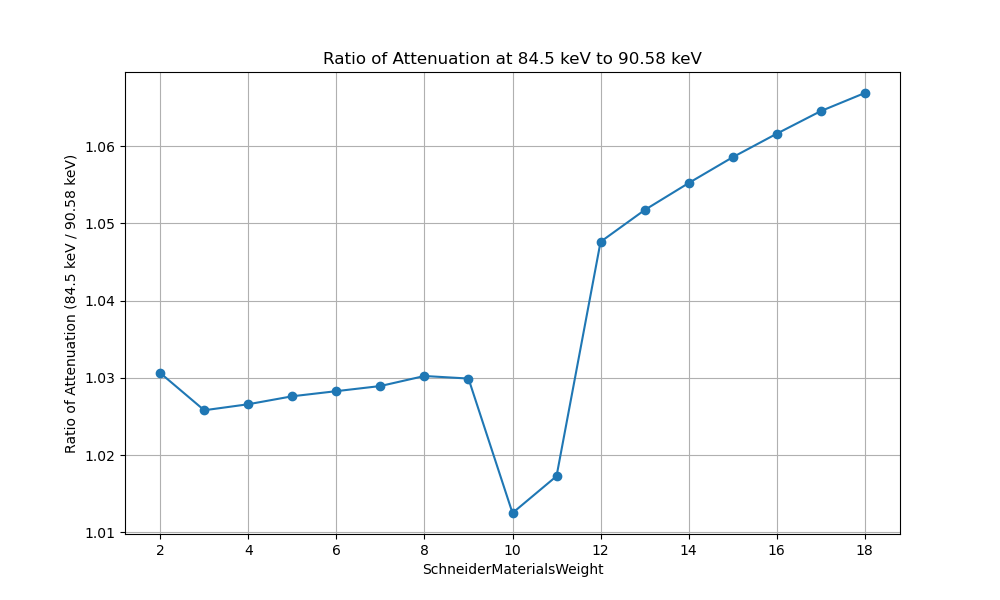

In [140]:
import matplotlib.pyplot as plt

# Attenuation values at 84.5 keV
attenuation_84_5 = [
    0.17910210739439197, 0.17687572488053876, 0.17710910773410357, 0.17753711955908738,
    0.17783015718907297, 0.17809930048056297, 0.1787670083094822, 0.17701223773430905,
    0.1860595172263332, 0.18913133623099349, 0.19015692640508683, 0.19295930041836112,
    0.1954247308368971, 0.19780363036284165, 0.19994113389652837, 0.20200708816857152,
    0.20369871455583963
]

# Attenuation values at 90.58 keV
attenuation_90_58 = [
    0.17377957285492182, 0.17242661055410696, 0.17252292022259638, 0.17276615296183606,
    0.17293999889490014, 0.17308999750144216, 0.17352008733520746, 0.17187167650076965,
    0.1837620291453401, 0.18592021635931988, 0.1815150408006873, 0.18346971723848057,
    0.18519892483148714, 0.18686100759843813, 0.18833864488455115, 0.18976172474271025,
    0.19093011949972974
]

# Calculate the ratio
ratio = [a / b for a, b in zip(attenuation_84_5, attenuation_90_58)]

# Plot the ratio
plt.figure(figsize=[10, 6])
plt.plot(range(2, 19), ratio, marker='o')
plt.xlabel('SchneiderMaterialsWeight')
plt.ylabel('Ratio of Attenuation (84.5 keV / 90.58 keV)')
plt.title('Ratio of Attenuation at 84.5 keV to 90.58 keV')
plt.grid(True)
plt.show()

In [91]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

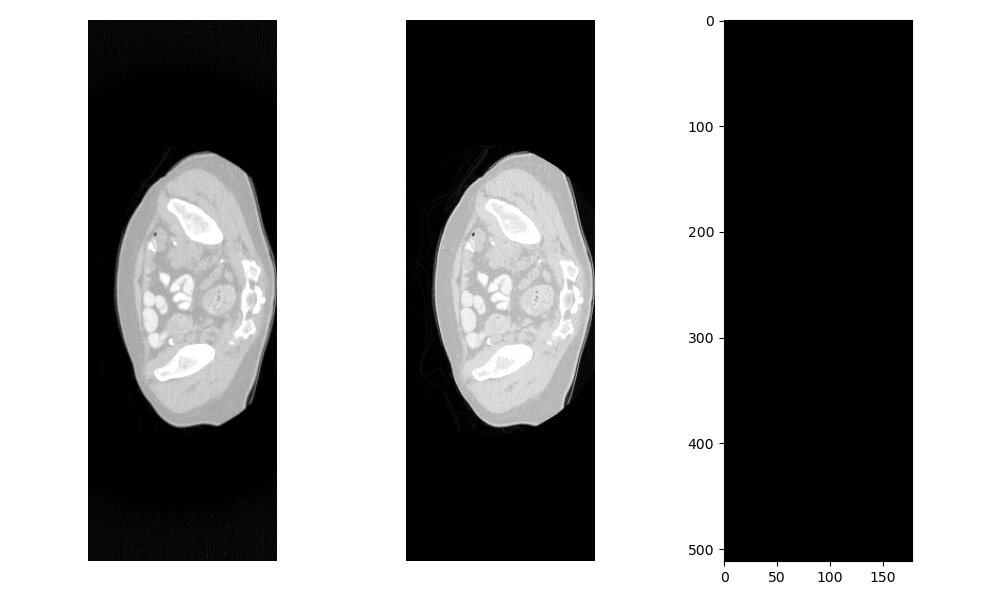

In [93]:
plt.figure(figsize=[10,6])
plt.subplot(131)
plt.imshow(np.flipud(phantom.img[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.img[40],40),vmax=np.percentile(phantom.img[40],98))
# plt.title('GECCO CBCT')
plt.axis('off')
plt.subplot(132)
plt.imshow(np.flipud(phantom.density[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.density[40],40),vmax=np.percentile(phantom.density[40],98))
# plt.title('Clinical CT')
plt.axis('off')
plt.subplot(133)
plt.imshow(np.flipud(phantom.phantom[40,:,:])==11,cmap='gray',aspect='equal')
# plt.title('Phantom')
# plt.axis('off')
plt.tight_layout()

In [94]:
phantom_img_high = phantom.img + 0.00001

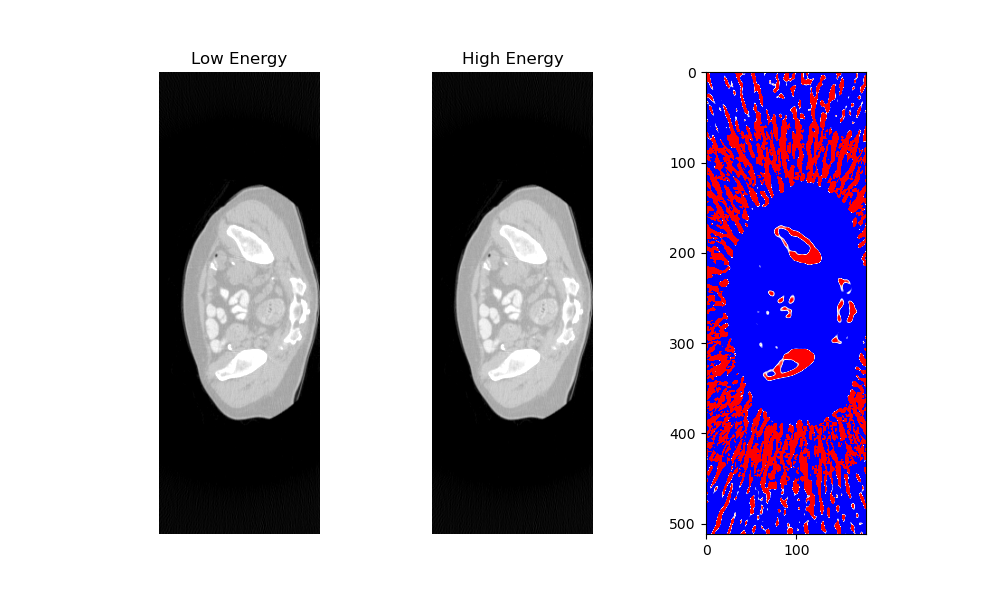

In [164]:
plt.figure(figsize=[10,6])
plt.subplot(131)
plt.imshow(np.flipud(phantom_img_low[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_low[40],40),vmax=np.percentile(phantom_img_low[40],98))
plt.title('Low Energy')
plt.axis('off')
plt.subplot(132)
plt.imshow(np.flipud(phantom_img_high[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_high[40],40),vmax=np.percentile(phantom_img_high[40],98))
plt.title('High Energy')
plt.axis('off')

# plt.imshow((phantom_img_high[40,:,:]-phantom_img_low[40,:,:]),cmap='bwr_r',aspect='equal')

# gaussian filter the images
from scipy.ndimage import gaussian_filter
img_low = gaussian_filter(phantom_img_low[40,:,:], sigma=2)
img_high = gaussian_filter(phantom_img_high[40,:,:], sigma=2)

plt.subplot(133)
img_sub = (img_low - img_high)/img_low
# img_sub[ phantom_img_low[40] < 0.02] = 0
# img_sub[ phantom_img_low[40] > 0.028] = 0
plt.imshow(-np.flipud(img_sub),cmap='bwr_r',aspect='equal',vmin=-0.0460,vmax=-0.04)

In [66]:
plt.close('all')

In [ ]:
# Make a plot with a dynamically adjusted window and level
plt.tight_layout()

plt.figure(figsize=[10,6])
plt.imshow((phantom_img_high[40,:,:]-phantom_img_low[40,:,:])/(phantom_img_low[40,:,:]),cmap='bwr_r',aspect='equal',vmin=-0.04,vmax=-0.02)
plt.colorbar()
plt.axis('off')

# window and level

# Another few energies

In [120]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([80, 80.1, 80.2])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False)

[2025-01-17 16:34:11,590] {patient_data.py:616} INFO - Making a list of angles
[2025-01-17 16:34:11,592] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-17 16:34:11,596] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
18
18
[2025-01-17 16:34:11,936] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-17 16:34:11,964] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-17 16:34:11,965] {ggems_simulate.py:622} INFO -     Simulating 80.0 keV
[2025-01-17 16:34:11,980] {ggems_simulate.py:701} INFO -         Attenuation at 80.0 keV for SchneiderMaterialsWeight2 is 0.18396462060873478
[2025-01-17 16:34:11,995] {ggems_simulate.py:701} INFO -         Attenuation at 80.0 keV for SchneiderMaterialsWeight3 is 0.18076898571869487
[2025-01-17 16:34:12,009] {ggems_simulate.py:701} INFO -         Attenuation at 80.0 keV for SchneiderMa

In [121]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

In [122]:
phantom_img_80 = phantom.img + 0.00001

In [123]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

spectrum.x = np.array([99, 99.1, 99.2])
spectrum.y = np.array([0,1,0])

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,480,conv_on=False)

[2025-01-17 16:34:25,173] {patient_data.py:616} INFO - Making a list of angles
[2025-01-17 16:34:25,174] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2025-01-17 16:34:25,177] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
18
18
[2025-01-17 16:34:25,409] {ggems_simulate.py:557} INFO -     Phantom is_patient: True, using mu_over_rho
[2025-01-17 16:34:25,430] {ggems_simulate.py:594} INFO - Running Simulations: 480 Projections
[2025-01-17 16:34:25,431] {ggems_simulate.py:622} INFO -     Simulating 100.0 keV
[2025-01-17 16:34:25,439] {ggems_simulate.py:701} INFO -         Attenuation at 100.0 keV for SchneiderMaterialsWeight2 is 0.15144224356431704
[2025-01-17 16:34:25,447] {ggems_simulate.py:701} INFO -         Attenuation at 100.0 keV for SchneiderMaterialsWeight3 is 0.15188768044174908
[2025-01-17 16:34:25,454] {ggems_simulate.py:701} INFO -         Attenuation at 100.0 keV for Schneid

In [124]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.0,noise_weight=1000000) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

In [125]:
phantom_img_99 = phantom.img + 0.00001

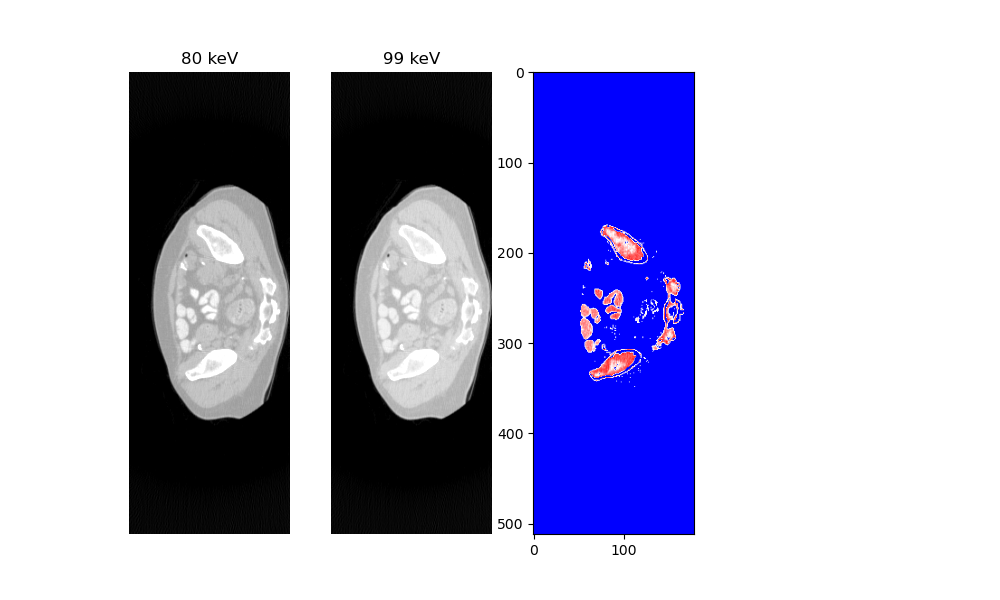

In [126]:
plt.figure(figsize=[10,6])
plt.subplot(141)
plt.imshow(np.flipud(phantom_img_80[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_80[40],40),vmax=np.percentile(phantom_img_80[40],98))
plt.title('80 keV')
plt.axis('off')
plt.subplot(142)
plt.imshow(np.flipud(phantom_img_99[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom_img_99[40],40),vmax=np.percentile(phantom_img_99[40],98))
plt.title('99 keV')
plt.axis('off')
plt.subplot(143)
img_sub = phantom_img_99[40,:,:]-phantom_img_80[40,:,:]
img_sub[ phantom_img_80[40] < 0.02] = 0
img_sub[ phantom_img_80[40] > 0.028] = 0
plt.imshow(np.flipud(img_sub),cmap='bwr_r',aspect='equal')


## Second layer

In [135]:
phantom = patient_data.patient_phantom(nrrd_file, 1e10, reload=True, sim_num=sim_num, second_layer=True)

[2024-06-05 13:40:33,219] {patient_data.py:69} INFO - Reloading phantom
[2024-06-05 13:40:33,219] {patient_data.py:154} INFO - Found existing directory. Using mhd file Pelvis_Prostate_Patient_5_phantom.mhd
[2024-06-05 13:40:33,271] {patient_data.py:184} INFO - Phantom loaded from pickle file fastmc_1e10_10angles.pkl
[2024-06-05 13:40:33,303] {patient_data.py:190} INFO - Loading ggems files

[2024-06-05 13:40:33,303] {patient_data.py:214} INFO - Using the second detector layer ggems files
[2024-06-05 13:40:33,384] {patient_data.py:259} INFO - ggems files loaded
[2024-06-05 13:40:33,384] {patient_data.py:260} INFO -     Scatter files:
[2024-06-05 13:40:33,385] {patient_data.py:263} INFO -         /home/berbecolab/Software/gecco-master/gecco/data/user_phantoms/Pelvis_Prostate_Patient_5/fastmc_output/fastmc_0.00_2-scatter.mhd
[2024-06-05 13:40:33,385] {patient_data.py:265} INFO -           Shape:(360, 360)
[2024-06-05 13:40:33,385] {patient_data.py:263} INFO -         /home/berbecolab/Soft

In [136]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(140,12)

# phantom.phantom = np.flip(phantom.phantom,axis=[2])
# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

# First layer filters
spectrum.filter('Cesium Iodide',0.6*0.71) # 71% fill factor
spectrum.filter('Si',1.1)

phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e20,360,conv_on=False)

[2024-06-05 13:40:33,767] {patient_data.py:609} INFO - Making a list of angles
[2024-06-05 13:40:33,767] {patient_data.py:637} INFO - Detector matching specifications: CsI-784-micrometer
[2024-06-05 13:40:33,770] {ggems_simulate.py:204} INFO - Initializing filter /home/berbecolab/Software/gecco-master/gecco/data/bowties/half_fan_mm.dat
[2024-06-05 13:40:33,953] {ggems_simulate.py:581} INFO - Running Simulations
[2024-06-05 13:40:33,953] {ggems_simulate.py:609} INFO -     Simulating 10 keV
[2024-06-05 13:40:33,959] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight2 is 10.349854284535223
[2024-06-05 13:40:33,966] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight3 is 5.647085846302243
[2024-06-05 13:40:33,971] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight4 is 6.434291404998359
[2024-06-05 13:40:33,976] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for 

In [137]:
phantom.correct_intensity(ml=False,crop=40)
# phantom.sim_angles = np.linspace(0,2*np.pi,10)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.4,noise_weight=100) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
# phantom.reconstruct_ggems(algo="FDK",filt='ram_lak')

AttributeError: 'patient_phantom' object has no attribute 'img'

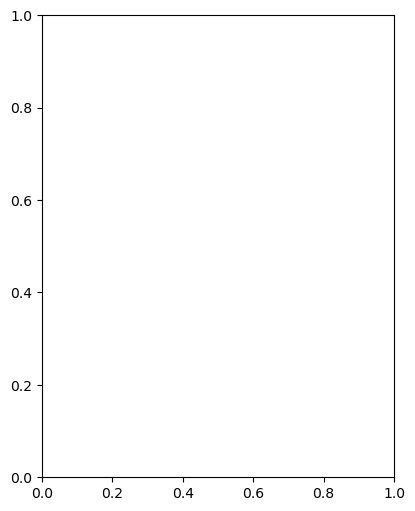

In [138]:
plt.figure(figsize=[10,6])
plt.subplot(121)
plt.imshow(np.flipud(phantom.img[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.img[40],40),vmax=np.percentile(phantom.img[40],98))
# plt.title('GECCO CBCT')
plt.axis('off')
plt.subplot(122)
plt.imshow(np.flipud(phantom.density[40,:,:]),cmap='gray',aspect='equal',vmin=np.percentile(phantom.density[40],40),vmax=np.percentile(phantom.density[40],98))
# plt.title('Clinical CT')
plt.axis('off')
plt.tight_layout()

In [158]:
from gecco.utils import gecco_python_script_pelvis, write_run_all_script


output_dir = 'gecco_data'

output_dir_abs = os.path.join(os.getcwd(),output_dir)

for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '_test.py'
    test_sim_dir = './test_gecco_scripts'
    sim_num = nrrd[3]

    gecco_python_script_pelvis(nrrd[0],os.path.join(test_sim_dir,test_file_name), 
                               output_dir_abs, sim_num, test=True)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./test_gecco_scripts/run_all.sh

0 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-05 14:10:59,330] {utils.py:1020} INFO - Script written to run all Python files in the directory


In [159]:
from gecco.utils import gecco_python_script_pelvis, write_run_all_script


output_dir = 'gecco_data'

output_dir_abs = os.path.join(os.getcwd(),output_dir)

for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '.py'
    test_sim_dir = './gecco_scripts'
    sim_num = nrrd[3]

    gecco_python_script_pelvis(nrrd[0],os.path.join(test_sim_dir,test_file_name), 
                               output_dir_abs, sim_num, test=False)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./gecco_scripts/run_all.sh

0 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-05 15:19:52,467] {utils.py:1020} INFO - Script written to run all Python files in the directory


In [163]:
from gecco.utils import gecco_python_script_pelvis, write_run_all_script


output_dir = 'gecco_data_matlab'

output_dir_abs = os.path.join(os.getcwd(),output_dir)

for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '.py'
    test_sim_dir = './gecco_scripts_matlab'
    sim_num = nrrd[3]

    gecco_python_script_pelvis(nrrd[0],os.path.join(test_sim_dir,test_file_name), 
                               output_dir_abs, sim_num, test=False,matlab=True)

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./gecco_scripts_matlab/run_all.sh

0 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/berbecolab/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-05 15:35:21,400] {utils.py:1020} INFO - Script written to run all Python files in the directory
